In [482]:
#%%
import math
import numpy as np
import inspect
import importlib

import scipy.interpolate

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Analysis                            import *

path_to_save_svg = "Saved_Data"



In [483]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [484]:
kgCO2_p_mm2_n65 = 0.94/100
kgCO2_p_mm2_n45 = 1.03/100
kgCO2_p_mm2_n40 = 1.06/100
kgCO2_p_mm2_n28 = 1.23/100
kgCO2_p_mm2_n20 = 1.23/100
kgCO2_p_mm2_n14 = 1.40/100

In [485]:
###############################################
# Based on  Apollo 3 datasheet
###############################################
MCU_Clock_freq = 20 #MHz

MCU_module = Node_module(name="Apollo3",
                            v      =1.8,
                            i_sleep=0.05)

apollo3_mm2   = 3.37*3.25
apollo3_CFemb = apollo3_mm2 * kgCO2_p_mm2_n40
print("Apollo 3 CF emb. : %.2f gCO2eq."%(apollo3_CFemb*1000))

#MCU_state_active  = Module_state("Active"     ,i = 0.045*    MCU_Clock_freq,duration = None)
MCU_state_active  = Module_state("Active"      ,i = 0.018*    MCU_Clock_freq,duration = None)
MCU_state_fftHW   = Module_state("512-ptFFT HW",i = (5.5/128)*MCU_Clock_freq,duration = None)

MCU_module.add_state(MCU_state_active)
MCU_module.add_state(MCU_state_fftHW)

Apollo 3 CF emb. : 116.10 gCO2eq.


In [486]:
###############################################
# Based on  STM32 L4 datasheet
###############################################
#fs = 10e3
#DMA_Clock_freq = fs/1e6 #MHz
#
#DMA_module = Node_module(name="DMA",
#                            v      =1.8,
#                            i_sleep=0.00)
#
#
#
#DMA_state_active  = Module_state("Active",i = (1/1000)*(1.4)*DMA_Clock_freq,duration = None)
#
#DMA_module.add_state(DMA_state_active)

In [487]:
###############################################
# Based on  STM32 L4 datasheet, coremark ex
###############################################
MCU_Clock_freq = 2 #MHz

MCU_module = Node_module(name="STM32F4",
                            v      =1.8,
                            i_sleep=6.9e-3)

stm32l4_mm2   = 3.132 * 3.127
stm32l4_CFemb = stm32l4_mm2 * kgCO2_p_mm2_n65 
print("STM32L4 (65nm proxy for 90nm) CF emb. : %.2f gCO2eq."%(stm32l4_CFemb*1000))

MCU_state_active  = Module_state("Active"      ,i = 0.145*    MCU_Clock_freq,duration = None)
MCU_state_fftHW   = Module_state("512-ptFFT HW",i = (5.5/128)*MCU_Clock_freq,duration = None)

MCU_module.add_state(MCU_state_active)
MCU_module.add_state(MCU_state_fftHW)

STM32L4 (65nm proxy for 90nm) CF emb. : 92.06 gCO2eq.


In [488]:
###############################################
# Based on  nRF52840 datasheet, coremark ex on LDO
###############################################
MCU_Clock_freq = 32 #MHz

MCU_module = Node_module(name="nRF52840",
                            v      =1.8,
                            i_sleep=3.16e-3)

nRF52840_mm2   = 3.5*3.6
nRF52840_CFemb = nRF52840_mm2 * (kgCO2_p_mm2_n65+kgCO2_p_mm2_n45)/2

MCU_state_active  = Module_state("Active"      ,i = (6.3/64)  *  MCU_Clock_freq,duration = None) # Assuming the LDO
MCU_state_fftHW   = Module_state("512-ptFFT HW",i = (5.5/128) *  MCU_Clock_freq,duration = None)

MCU_module.add_state(MCU_state_active)
MCU_module.add_state(MCU_state_fftHW)

In [489]:
Micro_module = Node_module(name="MicroIC",
                            v      =1.8,
                            i_sleep=0.000)

Micro_state_active  = Module_state("Active",i = 0.190,duration = None) #ICS-40310 
#Micro_state_active  = Module_state("Active",i = 0.650,duration = None) #Digital one

Micro_module.add_state(Micro_state_active)

In [490]:
fs = 16e3


Useful_Samples_p_melvec = 256
Samples_p_melvec        = 1024
N_melvec                = 184

MFCC_aquisition_duration         = Useful_Samples_p_melvec*N_melvec/fs
Audio_classification_p_day       = 0.95*np.floor(24*60*60 / MFCC_aquisition_duration)

print("Acquisition duration  : %.2fms "%((MFCC_aquisition_duration ) *1e3))
print("Inference p day       : %d "%(int(Audio_classification_p_day)))
print()

# From Thomas Antoine Master thesis

Cycles_p_inference      = (N_melvec*25033 / 0.62) * 0.25 / 0.7482 # Dongo Net     : Thomas
Cycles_p_inference      = 0.406 * 64e6 # Tiny-Chirp ML : CNN-Mel @ 64 MHz
Cycles_p_inference      = 0.210 * 48e6 # Dongo Net     : CNN-Mel @ 48 MHz

FFT_size = 1024
                                      #Thomas           #Dongo            # HSP AN6400
FFT_ratio_in_MFCC       =    np.mean([0.66*0.9398,      55538/71349,        0.6240])
print("Mean FFT Ratio in MFCC: %.2f"%FFT_ratio_in_MFCC)
FFTSW_Cycles            =    (25033*2*N_melvec) # Thomas TFE, based on 25033 cc/512-pt  RFFT
FFTSW_Cycles            =    (55538*  N_melvec) # Dongo     , based on 55538 cc/1024-pt RFFT

Radix = 2**4
FFTHW_Cycles            =    N_melvec*(2*(FFT_size*np.ceil(np.log2(FFT_size)/np.log2(Radix))))/2

Cycles_p_mfcc           =    FFTSW_Cycles / FFT_ratio_in_MFCC
Cycles_p_mfcc_wO_FFT    =   Cycles_p_mfcc - FFTSW_Cycles 


print("Cycle for audio classif        : %d"%(int(Cycles_p_mfcc+Cycles_p_inference)))
print("   ->Cycle for inference       : %d"%(int(Cycles_p_inference)))
print("   ->Cycle for MFCC            : %d"%(int(Cycles_p_mfcc)))
print("      ->Cycle for FFTs :   SW  : %d\t(One %i-pt RFFT : %i cc) "%(int(FFTSW_Cycles),FFT_size, int(FFTSW_Cycles/N_melvec)))
print("                           HW  : %d\t(One %i-pt RFFT : %i cc) "%(int(FFTHW_Cycles),FFT_size, int(FFTHW_Cycles/N_melvec)))
print("      ->Cycle for MFCC wO RFFT : %d"%(int(Cycles_p_mfcc_wO_FFT)))
print()

Inference_duration               = Cycles_p_inference/(MCU_Clock_freq*1e6)
MFCC_calculation_wO_FFT_duration = Cycles_p_mfcc_wO_FFT/(MCU_Clock_freq*1e6)
MFCC_FFT_SW_duration             = FFTSW_Cycles/(MCU_Clock_freq*1e6)
MFCC_FFT_HW_duration             = FFTHW_Cycles/(MCU_Clock_freq*1e6)

print("Audio classif duration : %.2fms "%((Inference_duration+MFCC_calculation_wO_FFT_duration+ MFCC_FFT_SW_duration) *1e3))
print("Inference duration     : %.2fms "%((Inference_duration ) *1e3))
print("MFCC wO FFT duration   : %.2fms "%((MFCC_calculation_wO_FFT_duration ) *1e3))
print("Duration for FFTs : SW : %.2fms  "%(MFCC_FFT_SW_duration*1e3))
print("                    HW : %.2fms  "%(MFCC_FFT_HW_duration*1e3))

print("")
print("Computation time per inference: SW FFT: %.2fms  "%((MFCC_FFT_SW_duration+Inference_duration+MFCC_calculation_wO_FFT_duration)*1e3))
print("Computation time per inference: HW FFT: %.2fms  "%((MFCC_FFT_HW_duration+Inference_duration+MFCC_calculation_wO_FFT_duration)*1e3))


print("")
print("Percentage of computing time per day: SW FFT: %.2f%%  "%(100*(MFCC_FFT_SW_duration+Inference_duration+MFCC_calculation_wO_FFT_duration)*Audio_classification_p_day/(24*60*60)))
print("Percentage of computing time per day: HW FFT: %.2f%%  "%(100*(MFCC_FFT_HW_duration+Inference_duration+MFCC_calculation_wO_FFT_duration)*Audio_classification_p_day/(24*60*60)))



Acquisition duration  : 2944.00ms 
Inference p day       : 27879 

Mean FFT Ratio in MFCC: 0.67
Cycle for audio classif        : 25236708
   ->Cycle for inference       : 10080000
   ->Cycle for MFCC            : 15156708
      ->Cycle for FFTs :   SW  : 10218992	(One 1024-pt RFFT : 55538 cc) 
                           HW  : 565248	(One 1024-pt RFFT : 3072 cc) 
      ->Cycle for MFCC wO RFFT : 4937716

Audio classif duration : 788.65ms 
Inference duration     : 315.00ms 
MFCC wO FFT duration   : 154.30ms 
Duration for FFTs : SW : 319.34ms  
                    HW : 17.66ms  

Computation time per inference: SW FFT: 788.65ms  
Computation time per inference: HW FFT: 486.97ms  

Percentage of computing time per day: SW FFT: 25.45%  
Percentage of computing time per day: HW FFT: 15.71%  


In [491]:

module_List = [MCU_module,Micro_module,radio_module_1V8,bme_module_1V8 ] # TRX_module , bme_module_3V3] # DMA_module

In [492]:

Audio_classification_w_SWFFT =  Node_task(  name = "Audio class. w. SW FFT", 
                        node_modules= module_List, 
                        subtasks   = [  Node_subtask(name='Acquisition',module=Micro_module,
                                        moduleState = Micro_state_active, stateDuration=MFCC_aquisition_duration),
                                        #Node_subtask(name='DMA transfer',module=DMA_module ,
                                        #moduleState = DMA_state_active     , stateDuration=(1/10)*MFCC_aquisition_duration),
                                        Node_subtask(name='MFCC w/o FFT'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=MFCC_calculation_wO_FFT_duration),
                                        Node_subtask(name='Inference'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=Inference_duration),
                                        Node_subtask(name='SW FFT'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=MFCC_FFT_SW_duration)
                        ],
                        taskDuration = MFCC_aquisition_duration, 
                        )

Audio_classification_w_HWFFT =  Node_task(  name = "Audio class. w. HW FFT", 
                        node_modules= module_List, 
                        subtasks   = [  Node_subtask(name='Acquisition',module=Micro_module,
                                        moduleState = Micro_state_active, stateDuration=MFCC_aquisition_duration),
                                        #Node_subtask(name='DMA transfer',module=DMA_module ,
                                        #moduleState = DMA_state_active     , stateDuration=(1/10)*MFCC_aquisition_duration),
                                        Node_subtask(name='MFCC w/o FFT'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=MFCC_calculation_wO_FFT_duration),
                                        Node_subtask(name='Inference'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=Inference_duration),
                                        Node_subtask(name='HW FFT'  ,module=MCU_module ,
                                        moduleState = MCU_state_fftHW  , stateDuration=MFCC_FFT_HW_duration)
                        ],
                        taskDuration = MFCC_aquisition_duration, 
                        )


In [493]:
task_TPHG_sensing_1V8 =  Node_task(  name = "TPHG meas.", 
                        node_modules= [MCU_module,bme_module_1V8 ], 
                        subtasks   = [   Node_subtask(name='Proc',module=MCU_module,
                                        moduleState=MCU_state_active, stateDuration=TPHG_duration+ MCU_BME_duration),
                                         Node_subtask(name='TPHG' ,module=bme_module_1V8 ,
                                        moduleState=bme_state_TPHG_1V8     , stateDuration=TPHG_duration)], 
                        taskDuration = TPHG_duration+ MCU_BME_duration, 
                         )

In [494]:
                    # 512-pt FFT is 46 % of MFCC : 
print("Cycle for total  : w. SW FFT %d     \t--- vs --- %d      \tw. HW FFT"%(int(Cycles_p_inference+Cycles_p_mfcc_wO_FFT+FFTSW_Cycles),int(Cycles_p_inference+Cycles_p_mfcc_wO_FFT+FFTHW_Cycles)))
print("Total Duration   : w. SW FFT %.2fms \t--- vs --- %.2fms  \tw. HW FFT"%(1e3*(Inference_duration+MFCC_calculation_wO_FFT_duration+MFCC_FFT_SW_duration), 1e3*(Inference_duration+MFCC_calculation_wO_FFT_duration+MFCC_FFT_HW_duration)))


print("Acquisition duration     : %.2fms "%((MFCC_aquisition_duration ) *1e3))

print("MFCC acquisition time : %.2fms --- vs --- %.2fms : Calc. time (Full SW)"%(MFCC_aquisition_duration*1e3, (Inference_duration+MFCC_calculation_wO_FFT_duration+MFCC_FFT_SW_duration) *1e3))
if MFCC_aquisition_duration<(Inference_duration+MFCC_calculation_wO_FFT_duration+MFCC_FFT_SW_duration):
    raise Exception("Melvec acquisition duration is shorter than processing duration!")

Cycle for total  : w. SW FFT 25236708     	--- vs --- 15582964      	w. HW FFT
Total Duration   : w. SW FFT 788.65ms 	--- vs --- 486.97ms  	w. HW FFT
Acquisition duration     : 2944.00ms 
MFCC acquisition time : 2944.00ms --- vs --- 788.65ms : Calc. time (Full SW)


In [495]:
node_LDO = LDO      (name = "Node LDO",   v_out = 1.8, i_q = 1e-3, v_in = 3.3, module_list = module_List)
node_Batt= Battery  (name = "Node Batt.", v = 3.3, capacity_mAh = 1800, i = 0, selfdischarge_p_year = 0)

node_lora = LoRa_Node(name= "IoT Node", module_list= module_List, PMU_composition =[node_LDO], Battery = node_Batt, radio_module = radio_module_1V8)

node= LoRa_Node_profile("Node_profile", node_lora,  RX_state=radio_state_TX_1V8,TX_state=radio_state_TX_1V8,
                    P_TX= PTX_PABOOST_1V8, I_TX=I_PABoost_1V8 ) 
              


In [496]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [497]:
Transmission_rate = 24*10 
this_task_tx = node.create_task_tx(name="TX-0", Ptx = 17,SF=12 ,Coding=1,Header=True,DE = 1,BW = 125e3, Payload = 50, TX_rate=Transmission_rate)
this_task_rx = node.create_task_rx(name="RX-0", RX_rate=Transmission_rate, RX_duration=0.250 )

In [503]:
def PL_model(d):
    return path_loss(d=d,f = 868e6, n=3)
    #return path_loss_PLd0(d=d, PLd0=94.40,d0=1, n=2.03)

this_task_tx.set_Path_loss_model(PL_model)
this_task_tx.set_distance( d= 1000)

In [499]:

node.add_task(task_TPHG_sensing_1V8,task_rate=24*12)

In [500]:
node.add_task(Audio_classification_w_SWFFT ,task_rate=1)
node.add_task(Audio_classification_w_HWFFT ,task_rate=1)

In [501]:
node.change_task_rate(Audio_classification_w_SWFFT      ,Audio_classification_p_day)
node.change_task_rate(Audio_classification_w_HWFFT      ,0)

-------------------------------------------------
            Tasks summary                        
-------------------------------------------------
Task name            : Sleep          TX-0           RX-0           TPHG meas.     Audio class. w. SW FFTAudio class. w. HW FFT
Times/day    [1/d]   : 1              240            240            288            27879.6499999999980              
Tot. durat.  [s]     : 3602.7302      30.7814        60.0000        628.7988       82077.6896     0.0000         
Tot. en./d   [mJ]    : 262.4445       2107.6756      4108.3373      12036.4266     158591.9970    0.0000         
Node en./d   [mJ]    : 177106.8810     
Average pow. [mW]    : 2.0498          
-------------------------------------------------
-----------------------------------------------------------------
                        Module summary                           
-----------------------------------------------------------------
Module       State        Active [s]   Energy [mJ

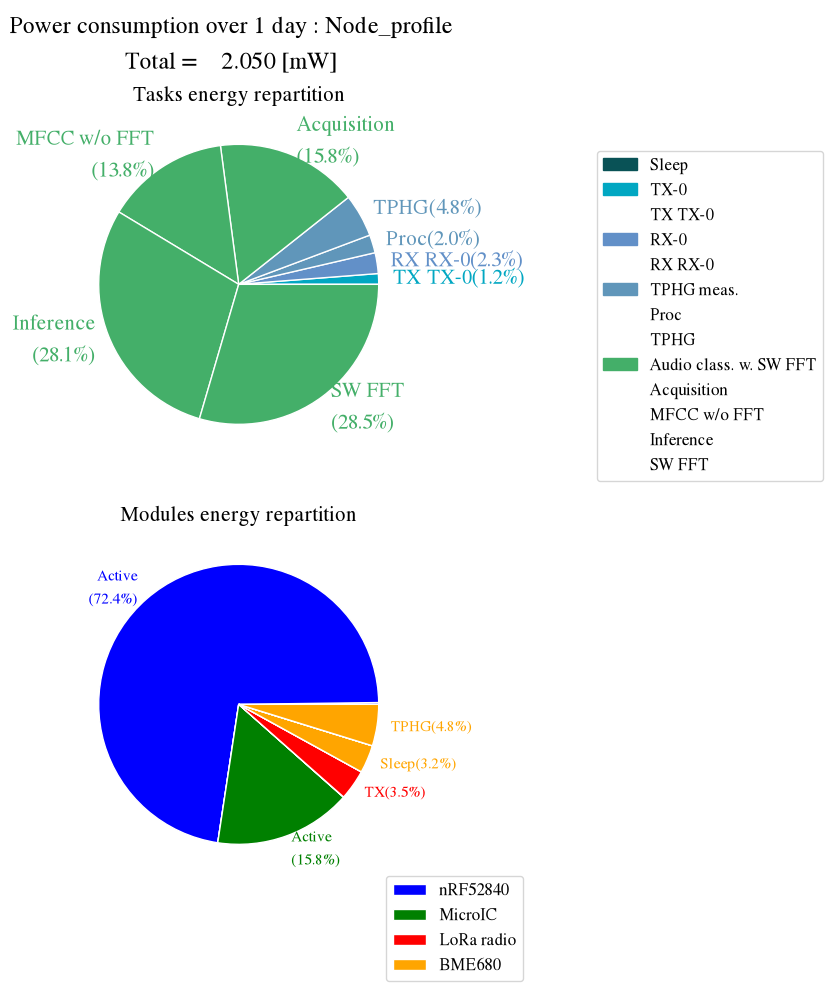

In [504]:
try:
    node.compute()
except Exception as e:
    print("An error occurred during the computation of the node profile:")
    print(e)
node.print_Tasks()
node.print_Modules()
node.plot_Power(plotSubtask=True)

In [505]:
node.change_task_rate(Audio_classification_w_HWFFT      ,Audio_classification_p_day)
node.change_task_rate(Audio_classification_w_SWFFT      ,0)

-------------------------------------------------
            Tasks summary                        
-------------------------------------------------
Task name            : Sleep          TX-0           RX-0           TPHG meas.     Audio class. w. SW FFTAudio class. w. HW FFT
Times/day    [1/d]   : 1              240            240            288            0              27879.649999999998
Tot. durat.  [s]     : 3602.7302      30.7814        60.0000        628.7988       0.0000         82077.6896     
Tot. en./d   [mJ]    : 262.4445       2107.6756      4108.3373      12036.4266     0.0000         109377.6319    
Node en./d   [mJ]    : 127892.5159     
Average pow. [mW]    : 1.4802          
-------------------------------------------------
-----------------------------------------------------------------
                        Module summary                           
-----------------------------------------------------------------
Module       State        Active [s]   Energy [mJ

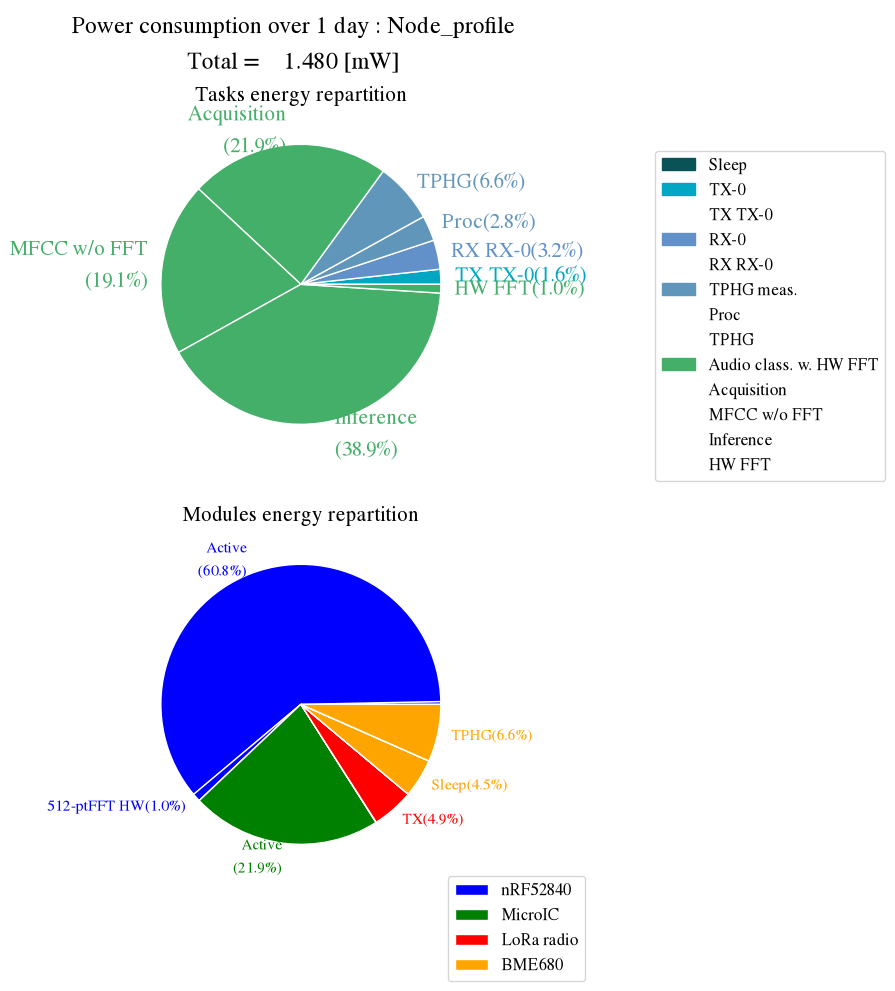

In [506]:
try:
    node.compute()
except Exception as e:
    print("An error occurred during the computation of the node profile:")
    print(e)
node.print_Tasks()
node.print_Modules()
node.plot_Power(plotSubtask=True)

In [507]:
show = 0

AA_series = 3
AA_footprint = 0.165
AA_cost      = 0.25 
Batt_footprint = AA_series*AA_footprint
Batt_cost      = AA_series*AA_cost

placementNnodes   = 100
decomNnodes       = 100
replacementNnodes = 10

transport_f =   transport_footprint(km_one_way = 1, 
                                    type ="Unit", 
                                    weight_g = 500,  
                                    unit_factor = 1,
                                    footprint_p_km = 0.350)

transport_c =   transport_cost( worker = 1, salary_p_hour = 20, work_hour =0.3, km_p_h = 50,km_one_way = 10, 
                                type ="Unit", 
                                weight_g = 500, cost_p_tkm =  0.2/1e3,
                                unit_factor = 1,cost_p_km = 0.2)
    

node_footprint = Node_BoM(  casing            =[0.709,    0.3932, 1.3259], #709
                            connectivtiy      =[0.517,    0.2262, 0.5817],
                            eol               =[0.0812,   0.0388, 0.1201],
                            memory            =[0,        0,      0     ],
                            others            =[0.0938,   0.0546, 0.1394],
                            pcb               =[1.17,     0.9403, 1.5696], #1.17
                            power_supply      =[0.132,    0.0446, 0.1751],
                            processing        =[0.366,    0.3665, 0.4537],
                            sensing           =[0.0539,   0.0539, 0.5561] + [0.080,0.080,0.080],
                            ui                =[0.0306,   0.0017, 0.1155],
                            transport         =[transport_f*show,transport_f*show,transport_f*show],
                            battery           =[Batt_footprint  ,Batt_footprint,Batt_footprint],
                            placement         =[transport_f,transport_f,transport_f],
                            replacement       =[transport_f,transport_f,transport_f],
                            decom             =[transport_f,transport_f,transport_f], 
                            placementNnodes   = placementNnodes,
                            decomNnodes       = decomNnodes,
                            replacementNnodes = replacementNnodes)


node_Cost   = Node_BoM(     casing            = 10          , #ABS , IP rated
                            connectivtiy      = 5.3         , #SX1276 : 5.3
                            eol               = 0           ,
                            memory            = 0           ,
                            others            = 1.42        , #MLCC : 0.05*15 + XTAL32MHz: 0.5 + R: 0.002*15 + D : 0.07*2  
                            pcb               = 1.17        , #PCB 60cm2 : 1.75 
                            power_supply      = 0.228       , #XC6206 : 0.228 + Diode and Transistor?
                            processing        = 3.65        , #Apollo3: 3.65
                            sensing           = 6.94        , #BME680 : 6.94
                            ui                = 0.54        , #Push button : 0.17*2 + LED SMD : 0.2*1
                            transport         = transport_c ,
                            battery           = Batt_cost   ,
                            placement         = transport_c ,
                            replacement       = transport_c ,
                            decom             = transport_c ,
                            placementNnodes   = 100,
                            decomNnodes       = 100,
                            replacementNnodes = 10)


3.6485000000000003


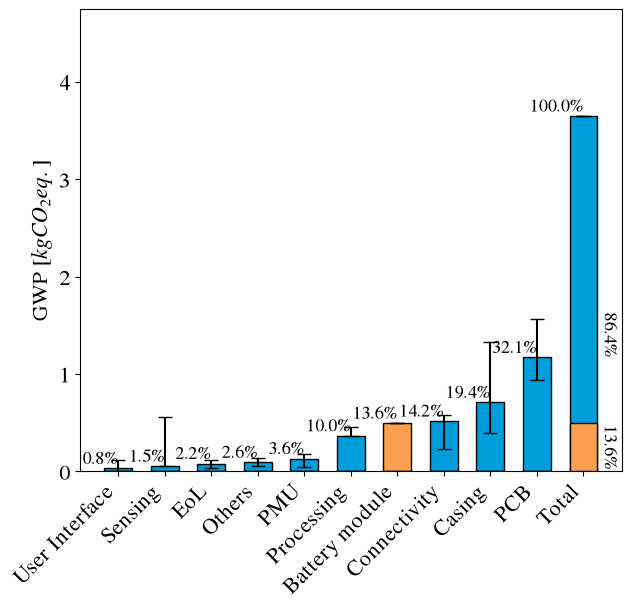

In [508]:
node_footprint.plot_footprint(filename = None,figsize=(7,6), separatePlot=False)